# APE08: Inferencia Estadística: Estimación de Parámetros e Intervalos de Confianza (Z y T de Student) - Grupo A


## Tarea 1-Intervalos de Confianza para Muestras Grandes (Distribución Z)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

# Datos de la muestra (Consumo energético en kWh)
np.random.seed(42)
n_grande = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)

# Estadísticos descriptivos (Estimadores puntuales)
media_muestral = np.mean(muestra_consumo)
desv_estandar = np.std(muestra_consumo, ddof=1) # s (muestral)
error_estandar = desv_estandar / np.sqrt(n_grande) # SE

# Cálculo del Intervalo de Confianza (95%)
nivel_confianza = 0.95
# loc = media muestral, scale = error estándar de la media
ic_inferior_z, ic_superior_z = norm.interval(confidence=nivel_confianza, loc=media_muestral, scale=error_estandar)

margen_error_z = (ic_superior_z - ic_inferior_z) / 2

print("--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---")
print(f"Tamaño de muestra (n): {n_grande}")
print(f"Media Muestral (Estimador puntual): {media_muestral:.2f} kWh")
print(f"Margen de Error: ±{margen_error_z:.2f} kWh")
print(f"IC al {nivel_confianza*100}%: [{ic_inferior_z:.2f}, {ic_superior_z:.2f}] kWh")

--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---
Tamaño de muestra (n): 100
Media Muestral (Estimador puntual): 345.33 kWh
Margen de Error: ±8.01 kWh
IC al 95.0%: [337.32, 353.34] kWh


## Tarea 2-Intervalos para Muestras Pequeñas (Distribución T de Student)

In [ ]:
import numpy as np
from scipy.stats import norm, t

# Muestra pequeña (n=12)
n_pequena = 12
np.random.seed(42)

muestra_agua = np.random.normal(loc=7.2, scale=0.5, size=n_pequena) # pH del agua
media = np.mean(muestra_agua)
error_estandar = np.std(muestra_agua, ddof=1) / np.sqrt(n_pequena)
grados_libertad = n_pequena - 1

# IC usando T de Student
ic_inf_t, ic_sup_t = t.interval(confidence=0.95, df=grados_libertad, loc=media, scale=error_estandar)
margen_error_t = (ic_sup_t - ic_inf_t) / 2

# IC usando Normal Z
ic_inf_z, ic_sup_z = norm.interval(confidence=0.95, loc=media, scale=error_estandar)
margen_error_z = (ic_sup_z - ic_inf_z) / 2

# Reporte de resultados corregido
print(f"Análisis para n={n_pequena}")
print(f"Media Muestral: {media:.3f} pH") # Variable corregida
print(f"Margen de Error (T): ±{margen_error_t:.3f}")
print(f"Margen de Error (Z): ±{margen_error_z:.3f}")
print(f"\nIC T de Student (95%): [{ic_inf_t:.3f}, {ic_sup_t:.3f}]")
print(f"IC Normal Z (95%):     [{ic_inf_z:.3f}, {ic_sup_z:.3f}]")
print(f"\nConclusión: El intervalo T es {(margen_error_t/margen_error_z - 1)*100:.2f}% más ancho que el Z.")

Análisis para n=12
Media Muestral: 7.348 pH
Margen de Error (T): ±0.236
Margen de Error (Z): ±0.211

IC T de Student (95%): [7.112, 7.584]
IC Normal Z (95%):     [7.137, 7.559]

Conclusión: El intervalo T es 12.30% más ancho que el Z.


#### T de student esta mejor pensado para manejar la falta de información, en cambio al usar Z, este pese a que da un rango más pequeño que T, la falta de información por una muestra tan pequeña provoca que haya más incertidumbre al Z no estar pensado para este tipo de situaciones.

## Tarea 3-Hito del Proyecto - Estimación de la Realidad Regional (ABP)


Inferencia con el 95% de confianza (Distribución Z)
Media Muestral: 49.3357
Valor Z crítico: 1.9600
Intervalo de Confianza: [-4.5502, 103.2216]


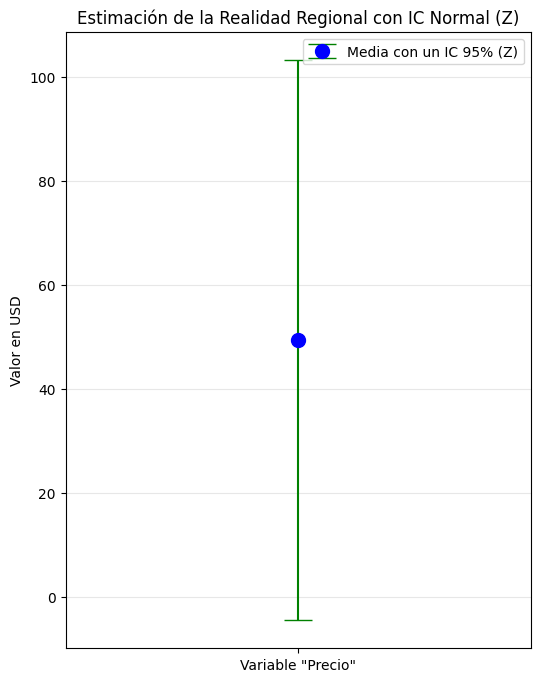

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

nombres_columnas = ["Fecha", "Tipo", "Emisor", "Cantidad", "Valor_Nominal",
                    "Precio", "Valor_Nominal_Total", "Monto_Efectivo",
                    "Casa_Origen", "Casa_Destino", "Bolsa"]

df_regional = pd.read_csv("BVG_Acciones_export.csv", names=nombres_columnas, skiprows=1)

df_regional['Precio'] = pd.to_numeric(df_regional['Precio'], errors='coerce')
variable_precio = df_regional['Precio'].dropna()
n = 100
muestra = variable_precio.sample(n=n, random_state=42)

# DISTRIBUCIÓN NORMAL (Z)
z_critico = stats.norm.ppf(q=0.975)

# Cálculo del Intervalo de Confianza
media_muestral = muestra.mean()
desviacion_muestral = muestra.std()
error_estandar = desviacion_muestral / np.sqrt(n)

ic_inferior = media_muestral - (z_critico * error_estandar)
ic_superior = media_muestral + (z_critico * error_estandar)

print(f"Inferencia con el 95% de confianza (Distribución Z)")
print(f"Media Muestral: {media_muestral:.4f}")
print(f"Valor Z crítico: {z_critico:.4f}")
print(f"Intervalo de Confianza: [{ic_inferior:.4f}, {ic_superior:.4f}]")

# Graficación
plt.figure(figsize=(6, 8))
plt.errorbar(x=[1], y=[media_muestral], yerr=[[media_muestral - ic_inferior], [ic_superior - media_muestral]],
             fmt='o', color='blue', ecolor='green', capsize=10, markersize=10, label='Media con un IC 95% (Z)')

plt.xticks([1], ['Variable "Precio"'])
plt.ylabel('Valor en USD')
plt.title('Estimación de la Realidad Regional con IC Normal (Z)')
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

### Dada la alta variabilidad de los datos en la variable Precios, se puede ver como Z tiene problemas para amortiguar esos valore atípicos, el margen de error supera a la media, lo que provoca que el rango se vaya a números negativos, aun cuando en la practica lo que se podría inferir es que el precio mínimo es cero, esto por la rigidez de Z y el hecho de que asume que con un tamaño lo suficientemente grande se podra seguir una distribución normal, cosa que no pasa por asimetria extrema. Por lo tanto, debido a la incertidumbre de los datos, no se puede tomar decisiones seguras a partir de este intervalo. T de student tambien tiene ese problema, por que intenta amortiguar esos valores grandes y alertar del riesgo.

## Tarea 4-El Impacto del Nivel de Confianza

Resultados
Confianza 80% -> Z: 1.282 -> Margen de Error: ±5.24 kWh
Confianza 90% -> Z: 1.645 -> Margen de Error: ±6.72 kWh
Confianza 95% -> Z: 1.960 -> Margen de Error: ±8.01 kWh
Confianza 99% -> Z: 2.576 -> Margen de Error: ±10.53 kWh


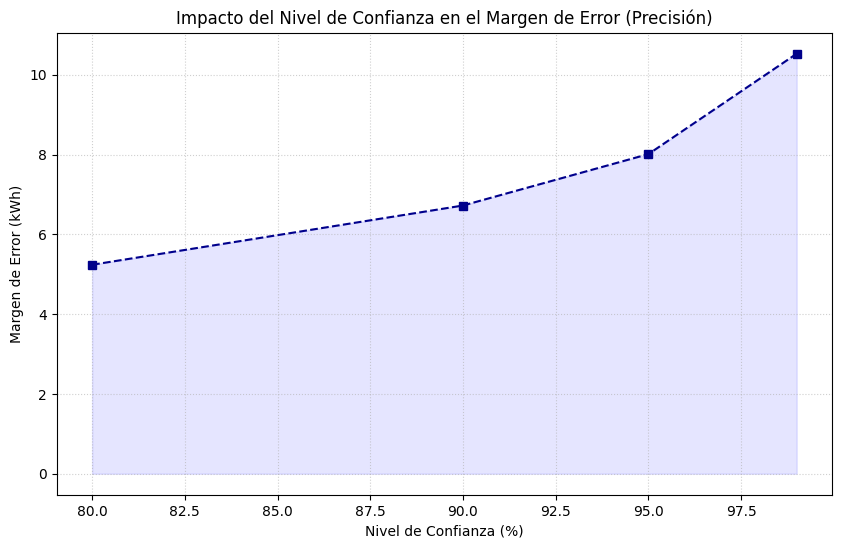

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)
n = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n)

# Estadísticos base para la estimación
s = np.std(muestra_consumo, ddof=1)  # Desviación estándar muestral
error_estandar = s / np.sqrt(n)      # Error estandar

# Se calcula el Margen de Error en diferentes niveles de confianza
niveles_confianza = [0.80, 0.90, 0.95, 0.99]
margenes_error = []

print("Resultados")
for nc in niveles_confianza:
    # Cálculo del valor crítico Z
    z_critico = norm.ppf (1 - (1 - nc) / 2)
    # Margen de Error
    me = z_critico * error_estandar
    margenes_error.append(me)
    print(f"Confianza {nc*100:.0f}% -> Z: {z_critico:.3f} -> Margen de Error: ±{me:.2f} kWh")

# Graficación
plt.figure(figsize=(10, 6))
plt.plot([c*100 for c in niveles_confianza], margenes_error, marker='s', linestyle='--', color='darkblue')
plt.fill_between([c*100 for c in niveles_confianza], margenes_error, alpha=0.1, color='blue')

plt.title('Impacto del Nivel de Confianza en el Margen de Error (Precisión)')
plt.xlabel('Nivel de Confianza (%)')
plt.ylabel('Margen de Error (kWh)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### Por los resultados que nos da el código, podemos ver cómo el margen de error va aumentando a medida que el nivel de confianza aumenta, por lo que se tiene una relación inversa con la precisión. Esto es algo lógico si consideramos que, a medida que el nivel de confianza crece, Z lo tiene que hacer también, y por lo tanto el margen de error también lo hace, dando como resultado una reducción de la fiabilidad de los datos. Aquí es donde entra el IC del 95%, pues se considera un equilibrio entre la precisión de la información obtenida y la seguridad de no tener un rango tan amplio que dé lugar a la omisión de información importante. Además de que ofrece un nivel de significancia del 5%, declarando un porcentaje de error bajo el que se tiene mejor precisión y detección de información, mejor que al trabajar con un IC de 99%.

## Preguntas de control

### **1. Defina con precisión técnica la diferencia conceptual entre una estimación puntual y una estimación por intervalos. ¿Por qué la estimación puntual por sí sola es insuficiente en ingeniería?**
#### La estimación puntual es un valor numérico único extraído de una muestra que se utiliza para aproximar un parámetro poblacional desconocido. Técnicamente, se define mediante un estimador que es una función de las variables muestrales. En cambio, una estimación por intervalos, es un rango de valores, calculado a partir de los datos muestrales, que tiene una probabilidad específica (nivel de confianza) de contener el parámetro poblacional. Se define mediante dos estadísticos, Linf y Lsup, de modo que el intervalo es Linf y Lsup, incorpora explícitamente el error estándar y el tamaño de la muestra, cuantificando la precisión de la inferencia.
#### En ingeniería, las decisiones implican riesgo y seguridad. Un estimador puntual es, casi con total seguridad, incorrecto en el sentido de que la probabilidad de que sea exactamente igual a un valor es cero para distribuciones continuas. Las razones principales de su insuficiencia son:
#### La ausencia de precisión, por lo que no indica si el valor obtenido es altamente confiable o si es producto de una muestra pequeña y volátil.
#### La ignorancia del error muestral, entonces dos procesos pueden tener la misma media puntual, pero uno puede presentar una dispersión que comprometa la integridad estructural o la tolerancia de una pieza.
#### La insuficiencia para la toma de decisiones de riesgo, pues para diseñar un puente o un circuito, el ingeniero necesita conocerlos límites del intervalo, que representan los peores escenarios, para aplicar factores de seguridad.

### **2. Explique la interpretación frecuentista correcta de un Intervalo de Confianza del 95%. (Evite el error común de decir "hay un 95% de probabilidad de que u caiga aquí").**

#### Si se repitiera un experimento una cantidad infinita de veces y calculamos un intervalo de confianza para cada muestra bajo el mismo procedimiento, el 95% de esos intervalos calculados contendrían el verdadero valor del parámetro u. En una sola ejecución, el parámetro está dentro del intervalo o no lo está. El "95%" se refiere a la fiabilidad del método de construcción del intervalo, no a la ubicación del parámetro en un intervalo específico ya calculado.

### **3. Al comparar las distribuciones Z Normal Estándar y la T de Student, ¿qué característica visual y matemática de la campana de la T de Student la hace idónea para compensar la falta de información en muestras pequeñas?**

#### Principalmente aporta estabilidad ya que la distribución T de student al ser más achatada y con colas más gruesas, al trabajar con un menor número de muestras, actúa a manera de amortiguador de los posibles errores y conclusiones falsas que puedan surgir del gráfico. Por parte de la matemática, los grados de libertad asumen el desconocimiento y dan paso a cubrir un mayor campo con la idea de atrapar datos bastante alejados, así mismo se eleva la varianza para ampliar el margen de error.

#### **4. Si en su Proyecto Integrador (Tarea 3) usted deseara reducir el Margen de Error a la mitad sin disminuir su Nivel de Confianza (manteniéndolo al 95%), ¿qué debe hacer metodológicamente con su recolección de datos (n)? Apóyese en la fórmula.**
#### Dada la fórmula del margen de error, debería disminuir el error estándar, es decir, obtener un tamaño de muestra 4 veces más grande, que dará paso a que al multiplicar el valor crítico Z por el error estándar se obtenga un margen de error menor.

### **5. Basado en su gráfico de la Tarea 4, ¿qué ocurre con el Intervalo de Confianza si buscamos un 100% de certeza teórica? ¿Tiene esto alguna utilidad analítica real para su proyecto en Loja?**
#### Si buscáramos un 100 % de certeza teórica se tendría que dar paso a un margen de error más grande, infinito prácticamente, por lo que sería inutil la información que se nos da. Pues tanto Z como T de Student están hechos para representar la incertidumbre, asignar un 100% de certeza haría que se tienda al infinito para encontrar siempre el parámetro real esperado. Y por lo tanto, la utilidad de esta certeza para nuestro proyecto es nula, pues se pierde toda confianza y precisión.
